# PULL THE DATASET FROM DRIVE

In [1]:
from google.colab import drive
import shutil
import os

print("1. Google Drive Bağlanıyor...")
drive.mount('/content/drive')

# Dosya yolları
drive_path = '/content/drive/MyDrive/cleaned_reviews.csv' # Drive'daki yeri
colab_path = '/content/cleaned_reviews.csv'               # Colab'in diski

print(f"2. Dosya Kopyalanıyor: {drive_path} -> {colab_path}")
print("   (Bu işlem dosya boyutuna göre 1-2 dakika sürebilir, lütfen bekle...)")

if os.path.exists(drive_path):
    # Drive'dan Colab'in hızlı diskine kopyalıyoruz (Eğitim hızlı olsun diye)
    shutil.copy(drive_path, colab_path)

    # Boyut Kontrolü
    size_mb = os.path.getsize(colab_path) / (1024*1024)
    print(f"✅ Kopyalama BAŞARILI! Dosya Boyutu: {size_mb:.2f} MB")

    if size_mb < 1000:
        print("🚨 UYARI: Dosya hala küçük görünüyor! Drive'a tam yüklenmemiş olabilir.")
    else:
        print("🚀 Dosya sapasağlam! Artık HÜCRE 1'i çalıştırabilirsin.")
else:
    print("❌ HATA: Dosya Drive'da bulunamadı! İsminin 'cleaned_reviews.csv' olduğundan ve Ana Dizinde olduğundan emin ol.")

1. Google Drive Bağlanıyor...
Mounted at /content/drive
2. Dosya Kopyalanıyor: /content/drive/MyDrive/cleaned_reviews.csv -> /content/cleaned_reviews.csv
   (Bu işlem dosya boyutuna göre 1-2 dakika sürebilir, lütfen bekle...)
✅ Kopyalama BAŞARILI! Dosya Boyutu: 1684.95 MB
🚀 Dosya sapasağlam! Artık HÜCRE 1'i çalıştırabilirsin.


# CLEANING THE DATA


In [2]:
import pandas as pd
import numpy as np
import ast
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score
from scipy.sparse import hstack, csr_matrix
import joblib

# Görsel ayarları
sns.set(style="darkgrid")
%matplotlib inline

print("--- ADIM 1: Veri Yükleniyor (Master Yöntem) ---")

# 1. VERİYİ KAYIPSIZ YÜKLEME
# Neden 'lineterminator=\n'?
# Çünkü yorumların içinde "Enter" tuşuna basılmış. Pandas bunu "yeni satır" sanıp
# dosyayı bozuk diye atlıyordu. Bu komutla "Hayır, o yorumun parçası" diyoruz.
try:
    df = pd.read_csv("cleaned_reviews.csv", lineterminator='\n')
except:
    # B planı
    df = pd.read_csv("cleaned_reviews.csv", engine='python', on_bad_lines='warn')

# KRİTİK KONTROL
print(f"✅ Yüklenen Toplam Satır: {len(df)}")
if len(df) < 10000:
    raise ValueError("HATA: Veri hala eksik! CSV dosyası Colab'e tam yüklenmemiş olabilir.")

# 2. TEMİZLİK
# Boş satırları atıyoruz (CSV dönüşüm hataları için)
#Ne Yapar: İçinde yorumu olmayan veya film ID'si eksik olan bozuk satırları siler. Model boş veriyle çalışamaz.
df = df.dropna(subset=['review_text', 'is_spoiler', 'movie_id']).reset_index(drop=True)

# 3. ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING)
print("Özellikler hazırlanıyor...")

# 'Genre' sütununu String'den Listeye çevirme ("['Drama']" -> ['Drama'])
def parse_list(x):
    if isinstance(x, list): return x
    try:
        return ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else []
    except:
        return []

df['genre'] = df['genre'].apply(parse_list)

# Türleri 1-0 sütunlarına çevirme (Action:1, Comedy:0 gibi) ONE HOT ENCODING
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genre'])
genre_df = pd.DataFrame(genres_encoded, columns=[f"Genre_{c}" for c in mlb.classes_])

# Kelime sayılarını hesaplama (Eğer yoksa)
if 'word_count' not in df.columns:
    df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))
if 'char_count' not in df.columns:
    df['char_count'] = df['review_text'].astype(str).apply(len)

# Meta-Veri Tablosunu Oluşturma (Sayısal Özellikler)
meta_data = pd.concat([df[['word_count', 'char_count']], genre_df], axis=1)

print("✅ ADIM 1 BİTTİ: Veri tam kadro hazır.")
df.head(2)

--- ADIM 1: Veri Yükleniyor (Master Yöntem) ---
✅ Yüklenen Toplam Satır: 573898
Özellikler hazırlanıyor...
✅ ADIM 1 BİTTİ: Veri tam kadro hazır.


,review_date,movie_id,user_id,is_spoiler,review_text,rating_x,review_summary,genre,rating_y,release_date,clean_text,length,word_count,char_count,year,split
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,"[Crime, Drama]",9.3,1994-10-14,"in its oscar year, shawshank redemption (writt...",843,843,4751,2006,train
1,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,"[Crime, Drama]",9.3,1994-10-14,the shawshank redemption is without a doubt on...,223,223,1218,2000,train


# Saving outcomes to drive

In [28]:
import os
import shutil
from google.colab import drive

# Google Drive'ı bağla (eğer bağlı değilse)
if not os.path.exists('/content/drive'):
    print("Google Drive bağlanıyor...")
    drive.mount('/content/drive')
else:
    print("Google Drive zaten bağlı.")

# Kaydedilecek klasör adı
output_folder = "/content/drive/MyDrive/Colab_Spoiler_Prediction_Outputs"
os.makedirs(output_folder, exist_ok=True)
print(f"\nÇıktılar '{output_folder}' klasörüne kaydediliyor...")

# Kaydedilecek dosyaların listesi
files_to_save = [
    'confusion_matrix.png',
    'roc_curve.png',
    'metrics_summary.png',
    'feature_importance.png',
    'regularization_heatmap.png',
    'regularization_comparison_report.csv',
    'test_predictions.csv',
    'feature_importance.csv',
    'lightgbm_model.txt',
    'lightgbm_model.pkl'
]

# Her bir dosyayı kopyala
for f in files_to_save:
    if os.path.exists(f):
        try:
            shutil.copy(f, os.path.join(output_folder, f))
            print(f"✅ '{f}' Drive'a kopyalandı.")
        except Exception as e:
            print(f"❌ '{f}' kopyalanırken hata oluştu: {e}")
    else:
        print(f"⚠️ '{f}' bulunamadı, kopyalanmadı.")

print("\n🚀 Tüm önemli çıktılar Google Drive'a kaydedildi!")

Google Drive zaten bağlı.

Çıktılar '/content/drive/MyDrive/Colab_Spoiler_Prediction_Outputs' klasörüne kaydediliyor...
✅ 'confusion_matrix.png' Drive'a kopyalandı.
✅ 'roc_curve.png' Drive'a kopyalandı.
✅ 'metrics_summary.png' Drive'a kopyalandı.
✅ 'feature_importance.png' Drive'a kopyalandı.
✅ 'regularization_heatmap.png' Drive'a kopyalandı.
✅ 'regularization_comparison_report.csv' Drive'a kopyalandı.
✅ 'test_predictions.csv' Drive'a kopyalandı.
✅ 'feature_importance.csv' Drive'a kopyalandı.
✅ 'lightgbm_model.txt' Drive'a kopyalandı.
✅ 'lightgbm_model.pkl' Drive'a kopyalandı.

🚀 Tüm önemli çıktılar Google Drive'a kaydedildi!


#SPLITTING THE DATA


In [3]:
print("--- ADIM 2: Bölümleme ve Vektörleştirme ---")

# 1. VERİ BÖLÜMLEME (DATA SPLIT)
# Neden 'GroupShuffleSplit'?
# Aynı filmin yorumları hem Eğitimde hem Testte olursa kopya çekmiş oluruz (Data Leakage).
# Filmleri (movie_id) gruplayarak ayırıyoruz.
print("Veri 'movie_id'ye göre bölünüyor...")
# burada n_split verinin kaç kere karıştırıp bölündüğünü ifade ediyor, bunu güncelleyerek cross validation yapaılabilir
# 0.7 train seti, 15 + 15 (test + val) ifade eder.
# 42 random state değeri sabit olduğu sürece hep aynı filmler aynı train setine veya test setine gider
splitter = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, temp_idx = next(splitter.split(df['review_text'], df['is_spoiler'], df['movie_id']))

# Veriyi fiziksel olarak ayırma
X_train_text = df['review_text'].iloc[train_idx].astype(str)
X_temp_text = df['review_text'].iloc[temp_idx].astype(str)

X_train_meta = meta_data.iloc[train_idx]
X_temp_meta = meta_data.iloc[temp_idx]

y_train = df['is_spoiler'].iloc[train_idx]
y_temp = df['is_spoiler'].iloc[temp_idx]
groups_temp = df['movie_id'].iloc[temp_idx]

# Kalan %30'u Val ve Test olarak bölme
splitter_val = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
val_idx, test_idx = next(splitter_val.split(X_temp_text, y_temp, groups_temp))

X_val_text, X_test_text = X_temp_text.iloc[val_idx], X_temp_text.iloc[test_idx]
X_val_meta, X_test_meta = X_temp_meta.iloc[val_idx], X_temp_meta.iloc[test_idx]
y_val, y_test = y_temp.iloc[val_idx], y_temp.iloc[test_idx]

print(f"Train Seti: {len(X_train_text)} (Hedef: ~400k)")

# 2. VEKTÖRLEŞTİRME (TF-IDF)
# Kelimeleri sayıya çeviriyoruz. RAM patlamasın diye en sık 5000 kelimeyi alıyoruz.
# Bu sayede veri setinde bir kez geçen ve noise olarak değerlendirilecek kelimelere takılmayıp overfittingi önlüyoruz.
# Yani yaptığımız aslında boyut indirgeme (dimensionality reduction)
print("TF-IDF matrisleri oluşturuluyor...")
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=5, max_df=0.9, stop_words='english')

# Sadece Train setinden öğreniyoruz (Fit)
X_train_tfidf = tfidf.fit_transform(X_train_text)
# Diğerlerine uyguluyoruz (Transform)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

# 3. BİRLEŞTİRME (STACKING)
# Metin Matrisi + Meta Veri Matrisi = FİNAL GİRDİ
"""
LightGBM'e tek bir matris veriyoruz ama bu matris iki parçadan oluşuyor.

Sol Taraf (TF-IDF): 5000 sütunluk kelime bilgisi. (İçerik bilgisi: "spoiler", "die", "end" kelimeleri var mı?)

Sağ Taraf (Meta-Data): 30-40 sütunluk yapısal bilgi. (Bağlam bilgisi: Türü Korku mu? Yorum 500 kelime mi?)

Kodun Yaptığı: hstack (Horizontal Stack) komutu, bu iki farklı matrisi yan yana yapıştırır.

Sonuç: Model bir karar verirken (bir ağaç dalını bölerken) şöyle düşünebilir:
"Eğer yorumun içinde 'killed' kelimesi geçiyorsa VE yorumun uzunluğu 200 kelimeden fazlaysa, bu kesin spoilerdır."
Sadece metinle bu bağlantıyı kuramazdı.
"""
print("Matrisler birleştiriliyor...")
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta.values)])
X_val_final = hstack([X_val_tfidf, csr_matrix(X_val_meta.values)])
X_test_final = hstack([X_test_tfidf, csr_matrix(X_test_meta.values)])

print(f"✅ ADIM 2 BİTTİ: Eğitim Matrisi Boyutu: {X_train_final.shape}")

--- ADIM 2: Bölümleme ve Vektörleştirme ---
Veri 'movie_id'ye göre bölünüyor...
Train Seti: 407628 (Hedef: ~400k)
TF-IDF matrisleri oluşturuluyor...
Matrisler birleştiriliyor...
✅ ADIM 2 BİTTİ: Eğitim Matrisi Boyutu: (407628, 5023)


#FIRST TRAINING WITHOUT TUNING (with default hyperparams)

In [13]:
print("--- ADIM 3: LightGBM Eğitimi ve CSV Çıktıları ---")
import lightgbm as lgb
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score
import joblib

# 1. MODEL AYARLARI
clf = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. EĞİTİM
# eğer 5o tur boyunca aynı pr-auc scoreu varsa modelin daha iyi eğitilemediğini
# ve overfittinge yol açmamak için durması gerektiğini söyler
print("Eğitim başladı...")
clf.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)

# 3. TEST VE RAPORLAMA
print("\n--- TEST SONUÇLARI ---")
y_pred_prob = clf.predict_proba(X_test_final)[:, 1]
y_pred = clf.predict(X_test_final)

pr_auc = average_precision_score(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"🎯 PR-AUC Score: {pr_auc:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['Non-Spoiler', 'Spoiler']))

# --- 4. CSV OLARAK KAYDETME İŞLEMLERİ (YENİ KISIM) ---

# A) Özellik Önem Tablosunu CSV Yapalım
feature_names = tfidf.get_feature_names_out().tolist() + list(X_train_meta.columns)
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance.to_csv("feature_importance.csv", index=False)
print("\n✅ 'feature_importance.csv' kaydedildi. (Rapora koymak için ideal)")
print("İlk 10 Özellik:\n", importance.head(10))

# B) Tahmin Sonuçlarını CSV Yapalım (Analiz için)
results_df = pd.DataFrame({
    'Actual_Label': y_test.values,
    'Predicted_Label': y_pred,
    'Predicted_Probability': y_pred_prob
})
results_df.to_csv("test_predictions.csv", index=False)
print("✅ 'test_predictions.csv' kaydedildi. (Hata analizi için kullanılabilir)")

# C) Modeli Kaydetme (Pickle yerine Text formatı)
# Modeli CSV yapamayız ama okunabilir TXT yapabiliriz.
clf.booster_.save_model('lightgbm_model.txt')
print("✅ Model 'lightgbm_model.txt' olarak kaydedildi.")

--- ADIM 3: LightGBM Eğitimi ve CSV Çıktıları ---
Eğitim başladı...
[LightGBM] [Info] Number of positive: 107230, number of negative: 300398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 5.117965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261276
[LightGBM] [Info] Number of data points in the train set: 407628, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's average_precision: 0.539	valid_0's binary_logloss: 0.583427
[200]	valid_0's average_precision: 0.55729	valid_0's binary_logloss: 0.569033
[300]	valid_0's average_precision: 0.564176	valid_0's binary_logloss: 0.562604
[400]	valid_0's average_precision: 0.566699	valid_0's binary_logloss: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🎯 PR-AUC Score: 0.5675
ROC-AUC Score: 0.7672

Sınıflandırma Raporu:
              precision    recall  f1-score   support

 Non-Spoiler       0.86      0.73      0.79     59145
     Spoiler       0.47      0.65      0.55     21243

    accuracy                           0.71     80388
   macro avg       0.66      0.69      0.67     80388
weighted avg       0.75      0.71      0.72     80388


✅ 'feature_importance.csv' kaydedildi. (Rapora koymak için ideal)
İlk 10 Özellik:
          Feature  Importance
5001  char_count         214
5000  word_count         195
4185    spoilers         193
2951       movie         173
4183     spoiler         164
1647        film         136
3890       scene         132
3035      movies         107
2476      killed         102
1392         end          99
✅ 'test_predictions.csv' kaydedildi. (Hata analizi için kullanılabilir)
✅ Model 'lightgbm_model.txt' olarak kaydedildi.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# GRAPHS

--- HATA TOLERANSLI GÖRSELLEŞTİRME (SMART VIZ) ---
✅ Dosya bulundu ve okundu: test_predictions.csv
   Sütunlar: ['Actual_Label', 'Predicted_Label', 'Predicted_Probability']


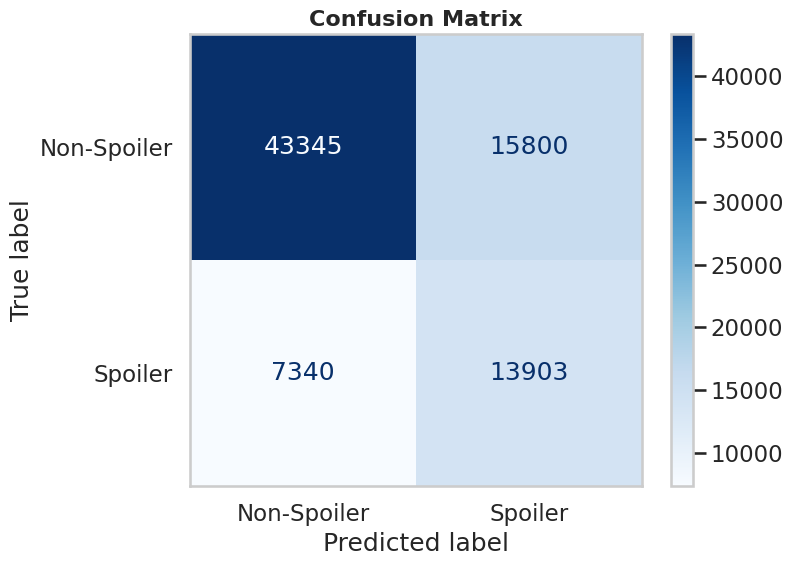

✅ Saved: confusion_matrix.png


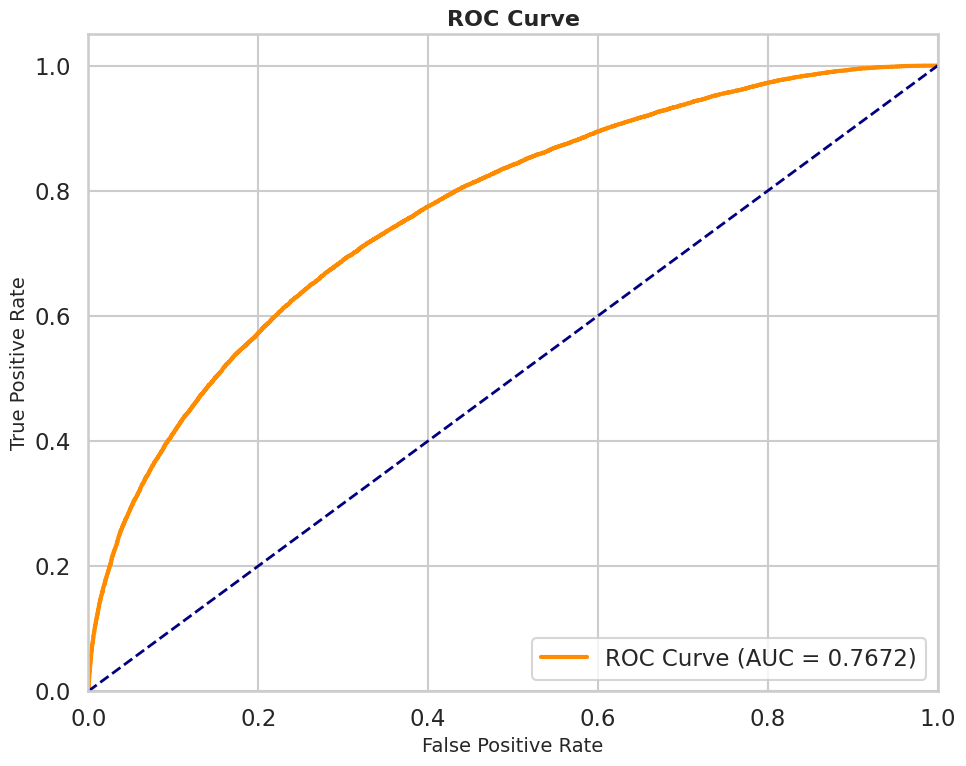

✅ Saved: roc_curve.png


/tmp/ipython-input-56861026.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Metric', y='Score', data=metrics_df, palette='magma')


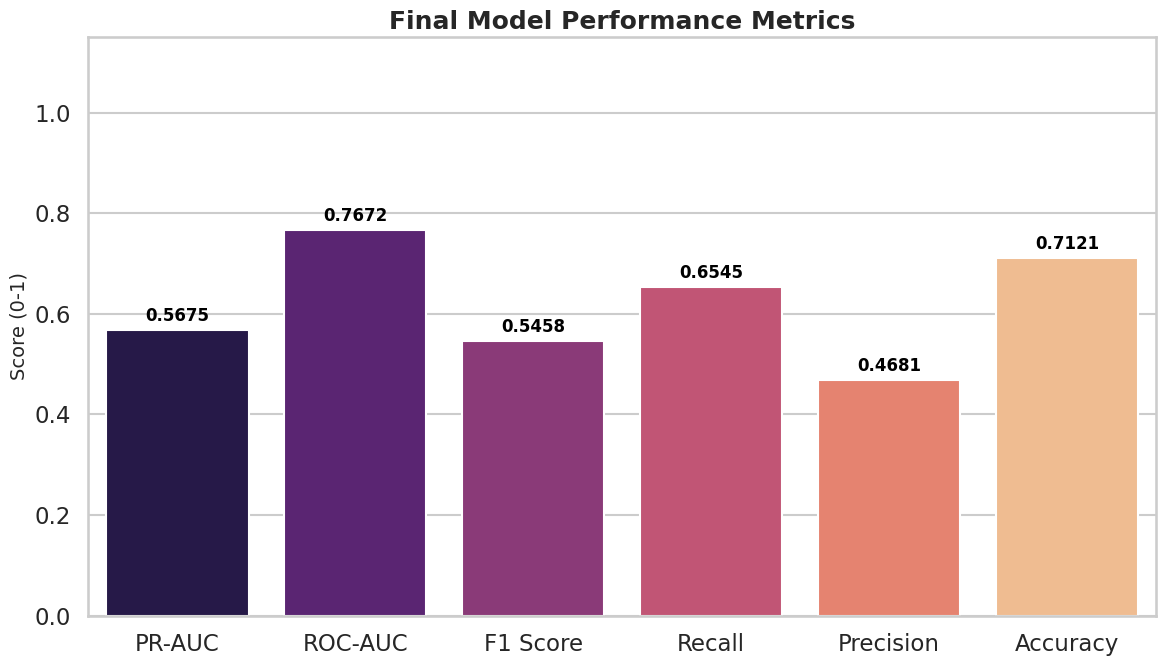

✅ Saved: metrics_summary.png


/tmp/ipython-input-56861026.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


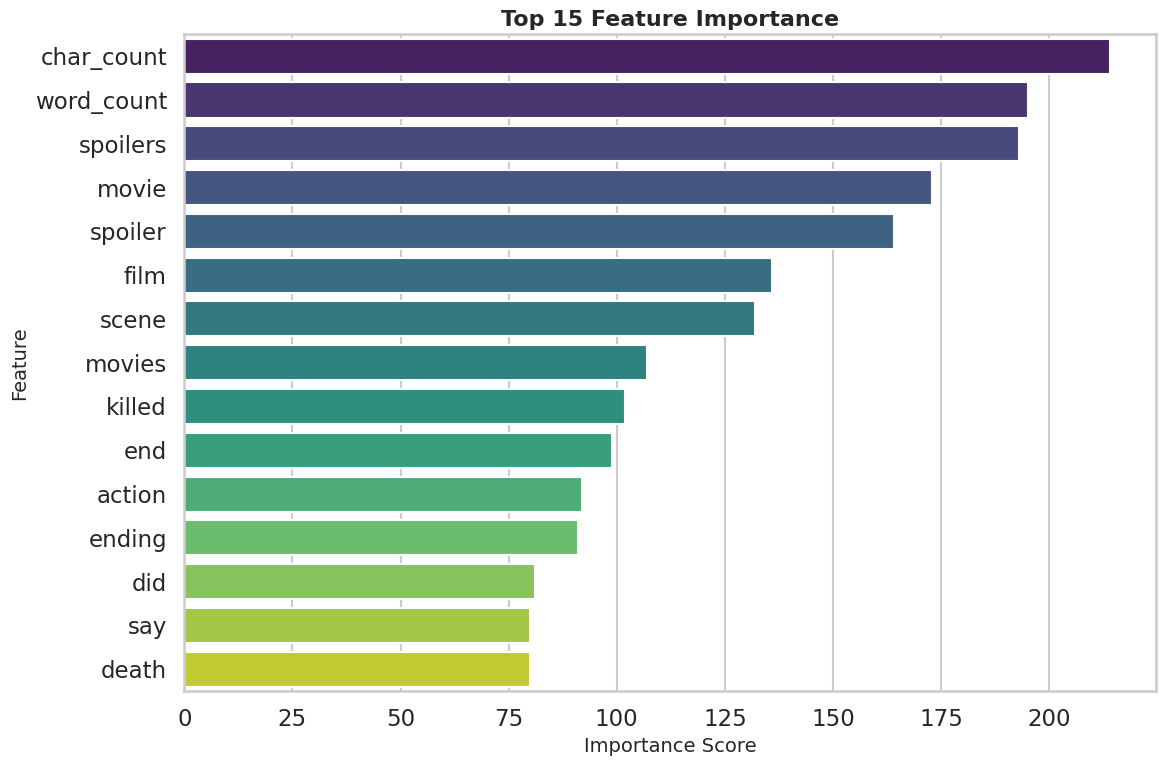

✅ Saved: feature_importance.png (Source: feature_importance.csv)


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import os

print("--- HATA TOLERANSLI GÖRSELLEŞTİRME (SMART VIZ) ---")

# Görsel Ayarları
sns.set(style="whitegrid", context="talk")

# 1. DOSYAYI BUL VE OKU
# Hangi dosya varsa onu okumayı dene
possible_files = [
    'final_test_results.csv',
    'model_results.csv',
    'test_predictions.csv',
    'spoiler_predictions.csv',
    'spoiler_predictions_optimized.csv'
]

results_df = None
loaded_file = ""

for f in possible_files:
    if os.path.exists(f):
        try:
            results_df = pd.read_csv(f)
            loaded_file = f
            print(f"✅ Dosya bulundu ve okundu: {f}")
            break
        except:
            continue

if results_df is None:
    raise FileNotFoundError("❌ HİÇBİR SONUÇ DOSYASI BULUNAMADI! Lütfen önce eğitim hücresini çalıştırın.")

# 2. SÜTUN İSİMLERİNİ OTOMATİK EŞLEŞTİRME
# Farklı dosyalarda farklı isimler olabilir, hepsini kontrol edelim.
cols = results_df.columns
print(f"   Sütunlar: {list(cols)}")

# Gerçek Etiket (y_true)
if 'true_label' in cols: y_true = results_df['true_label']
elif 'Actual_Label' in cols: y_true = results_df['Actual_Label']
elif 'true_is_spoiler' in cols: y_true = results_df['true_is_spoiler']
else: raise KeyError("Gerçek etiket sütunu bulunamadı!")

# Tahmin (y_pred)
if 'predicted_label_optimal' in cols: y_pred = results_df['predicted_label_optimal']
elif 'predicted_label' in cols: y_pred = results_df['predicted_label']
elif 'Predicted_Label' in cols: y_pred = results_df['Predicted_Label']
elif 'final_prediction' in cols: y_pred = results_df['final_prediction']
else: raise KeyError("Tahmin etiketi sütunu bulunamadı!")

# Olasılık (y_prob)
if 'predicted_prob' in cols: y_prob = results_df['predicted_prob']
elif 'predicted_probability' in cols: y_prob = results_df['predicted_probability']
elif 'Predicted_Probability' in cols: y_prob = results_df['Predicted_Probability']
elif 'predicted_spoiler_prob' in cols: y_prob = results_df['predicted_spoiler_prob']
else: raise KeyError("Olasılık sütunu bulunamadı!")

# --- 3. GRAFİKLERİ OLUŞTUR ---

# GRAPH 1: CONFUSION MATRIX
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Spoiler', 'Spoiler'])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print("✅ Saved: confusion_matrix.png")

# GRAPH 2: ROC CURVE
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()
print("✅ Saved: roc_curve.png")

# GRAPH 3: METRICS SUMMARY
metrics = {
    'PR-AUC': average_precision_score(y_true, y_prob),
    'ROC-AUC': roc_auc_score(y_true, y_prob),
    'F1 Score': f1_score(y_true, y_pred),
    'Recall': recall_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred),
    'Accuracy': accuracy_score(y_true, y_pred)
}

metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Score'])

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Metric', y='Score', data=metrics_df, palette='magma')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 10),
                   textcoords='offset points',
                   fontsize=12, color='black', weight='bold')

plt.ylim(0, 1.15)
plt.title('Final Model Performance Metrics', fontsize=18, fontweight='bold')
plt.ylabel('Score (0-1)', fontsize=14)
plt.xlabel('', fontsize=14)
plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=300)
plt.show()
print("✅ Saved: metrics_summary.png")

# GRAPH 4: FEATURE IMPORTANCE (Eğer dosya varsa)
importance_files = ['final_feature_importance.csv', 'feature_importance.csv']
found_imp = False
for f in importance_files:
    if os.path.exists(f):
        try:
            importance_df = pd.read_csv(f)
            plt.figure(figsize=(12, 8))
            top_features = importance_df.head(15)
            sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
            plt.title('Top 15 Feature Importance', fontsize=16, fontweight='bold')
            plt.xlabel('Importance Score', fontsize=14)
            plt.ylabel('Feature', fontsize=14)
            plt.tight_layout()
            plt.savefig('feature_importance.png', dpi=300)
            plt.show()
            print(f"✅ Saved: feature_importance.png (Source: {f})")
            found_imp = True
            break
        except:
            continue

if not found_imp:
    print("⚠️ Feature Importance dosyası bulunamadı, grafik çizilemedi.")



#  tuning with all hyperparameters

In [ ]:
import pandas as pd
import numpy as np
import ast
import lightgbm as lgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.sparse import hstack, csr_matrix
import os
import time

print("--- SIRALI TUNING (GÜNCELLENMİŞ DEĞERLERLE) ---")

# --- 1. VERİ HAZIRLIĞI ---
if not os.path.exists("cleaned_reviews.csv"):
    raise FileNotFoundError("Dosya bulunamadı! Lütfen cleaned_reviews.csv yükle.")

try:
    df = pd.read_csv("cleaned_reviews.csv", lineterminator='\n')
except:
    df = pd.read_csv("cleaned_reviews.csv", engine='python', on_bad_lines='warn')

df = df.dropna(subset=['review_text', 'is_spoiler', 'movie_id']).reset_index(drop=True)

# Türleri ve Özellikleri İşle
df['genre'] = df['genre'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith('[') else [])
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genre'])
genre_df = pd.DataFrame(genres_encoded, columns=[f"Genre_{c}" for c in mlb.classes_])

if 'word_count' not in df.columns:
    df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))
if 'char_count' not in df.columns:
    df['char_count'] = df['review_text'].astype(str).apply(len)

meta_data = pd.concat([df[['word_count', 'char_count']], genre_df], axis=1)

# Bölümleme
splitter = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, _ = next(splitter.split(df['review_text'], df['is_spoiler'], df['movie_id']))

X_train_text = df['review_text'].iloc[train_idx].astype(str)
y_train = df['is_spoiler'].iloc[train_idx]
groups_train = df['movie_id'].iloc[train_idx]

# Vektörleştirme
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=5, max_df=0.9, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_train_final = hstack([X_train_tfidf, csr_matrix(meta_data.iloc[train_idx].values)])

# --- 2. ALT ÖRNEKLEM  ---
TUNING_SIZE = 20000
if X_train_final.shape[0] < TUNING_SIZE:
    TUNING_SIZE = X_train_final.shape[0]

print(f"\n⚡ Tuning, {TUNING_SIZE} satırlık alt küme üzerinde yapılıyor...")
np.random.seed(42)
sample_indices = np.random.choice(X_train_final.shape[0], TUNING_SIZE, replace=False)

X_tune = X_train_final[sample_indices]
y_tune = y_train.iloc[sample_indices]
groups_tune = groups_train.iloc[sample_indices]

# --- 3. SIRALI TUNING MOTORU  ---

# Başlangıç Parametreler
current_params = {
    'random_state': 42,
    'n_jobs': -1,
    'class_weight': 'balanced',
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'n_estimators': 100,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'reg_alpha': 0,
    'reg_lambda': 0
}

# Denenecek Parametreler Listesi
tuning_agenda = [

    ('n_estimators', [50, 100, 300, 500]),

    ('learning_rate', [0.01, 0.05, 0.1]),


    ('num_leaves', [15, 31, 63]),


    ('max_depth', [5, 10, 15, 20, 30]),


    ('reg_alpha', [0, 0.1, 0.5, 1]),

    ('reg_lambda', [0, 0.1, 0.5])
]

print("\n PARAMETRE OPTİMİZASYONU ..\n")

gkf = GroupKFold(n_splits=3)

for param_name, param_values in tuning_agenda:
    print(f"🔎 Tuning: {param_name} | Denenecekler: {param_values}")

    best_score = -1
    best_val = None

    for val in param_values:
        temp_params = current_params.copy()
        temp_params[param_name] = val

        model = lgb.LGBMClassifier(**temp_params)

        scores = cross_val_score(model, X_tune, y_tune, groups=groups_tune, cv=gkf, scoring='average_precision', n_jobs=-1)
        mean_score = np.mean(scores)

        print(f"   -> Değer: {val} | Skor (PR-AUC): {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_val = val

    current_params[param_name] = best_val
    print(f" EN İYİ HİPERPARAMETRE DEĞERİ: {param_name} = {best_val} (Skor: {best_score:.4f})\n")
    print("-" * 40)

print("\n OPTİMİZASYON TAMAMLANDI!")
print("Final Parametre Seti:")
print(current_params)

--- SIRALI TUNING (GÜNCELLENMİŞ DEĞERLERLE) ---

⚡ Tuning, 20000 satırlık alt küme üzerinde yapılıyor...

 PARAMETRE OPTİMİZASYONU ..

🔎 Tuning: n_estimators | Denenecekler: [50, 100, 300, 500]
   -> Değer: 50 | Skor (PR-AUC): 0.5164
   -> Değer: 100 | Skor (PR-AUC): 0.5251
   -> Değer: 300 | Skor (PR-AUC): 0.5137
   -> Değer: 500 | Skor (PR-AUC): 0.5054
 EN İYİ HİPERPARAMETRE DEĞERİ: n_estimators = 100 (Skor: 0.5251)

----------------------------------------
🔎 Tuning: learning_rate | Denenecekler: [0.01, 0.05, 0.1]
   -> Değer: 0.01 | Skor (PR-AUC): 0.5057
   -> Değer: 0.05 | Skor (PR-AUC): 0.5251
   -> Değer: 0.1 | Skor (PR-AUC): 0.5184
 EN İYİ HİPERPARAMETRE DEĞERİ: learning_rate = 0.05 (Skor: 0.5251)

----------------------------------------
🔎 Tuning: num_leaves | Denenecekler: [15, 31, 63]
   -> Değer: 15 | Skor (PR-AUC): 0.5216
   -> Değer: 31 | Skor (PR-AUC): 0.5251
   -> Değer: 63 | Skor (PR-AUC): 0.5216
 EN İYİ HİPERPARAMETRE DEĞERİ: num_leaves = 31 (Skor: 0.5251)

-----------

# GRID SEARCH tuning for num_leaves and max_depth (without regularization)

In [21]:
import pandas as pd
import numpy as np
import ast
import lightgbm as lgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, GroupKFold
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.sparse import hstack, csr_matrix
import os

print("--- GRID SEARCH: (NO REGULARIZATION) ---")

# --- 1. VERİ YÜKLEME VE HAZIRLIK ---
print("1. Veri Yükleniyor...")
if not os.path.exists("cleaned_reviews.csv"):
    raise FileNotFoundError("Dosya yok! Lütfen cleaned_reviews.csv yükle.")

try:
    df = pd.read_csv("cleaned_reviews.csv", lineterminator='\n')
except:
    df = pd.read_csv("cleaned_reviews.csv", engine='python', on_bad_lines='warn')

df = df.dropna(subset=['review_text', 'is_spoiler', 'movie_id']).reset_index(drop=True)

# Türleri düzeltme
df['genre'] = df['genre'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith('[') else [])

# Özellik Mühendisliği
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genre'])
genre_df = pd.DataFrame(genres_encoded, columns=[f"Genre_{c}" for c in mlb.classes_])

if 'word_count' not in df.columns:
    df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))
if 'char_count' not in df.columns:
    df['char_count'] = df['review_text'].astype(str).apply(len)

meta_data = pd.concat([df[['word_count', 'char_count']], genre_df], axis=1)

# --- 2. BÖLÜMLEME VE VEKTÖRLEŞTİRME ---
print("2. Matrisler Oluşturuluyor...")
splitter = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, _ = next(splitter.split(df['review_text'], df['is_spoiler'], df['movie_id']))

X_train_text = df['review_text'].iloc[train_idx].astype(str)
y_train = df['is_spoiler'].iloc[train_idx]
groups_train = df['movie_id'].iloc[train_idx]

# TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=5, max_df=0.9, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_text)

# Birleştirme (Stacking)
X_train_final = hstack([X_train_tfidf, csr_matrix(meta_data.iloc[train_idx].values)])

# --- 3. GRID SEARCH HAZIRLIĞI (Subsampling) ---
SAMPLE_SIZE = 20000
if X_train_final.shape[0] < SAMPLE_SIZE: SAMPLE_SIZE = X_train_final.shape[0]

print(f"\n⚡ Grid Search, {SAMPLE_SIZE} satırlık alt küme üzerinde yapılıyor...")
np.random.seed(42)
sample_indices = np.random.choice(X_train_final.shape[0], SAMPLE_SIZE, replace=False)

X_tune = X_train_final[sample_indices]
y_tune = y_train.iloc[sample_indices]
groups_tune = groups_train.iloc[sample_indices]

# --- 4. PARAMETRE IZGARASI ---
param_grid = {
    # Karmaşıklık Ayarları
    'num_leaves': [15, 31, 63],
    'max_depth': [10, 20, -1]
}

# MODEL AYARLARI (REGULARIZATION KAPATILDI)
lgbm = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    class_weight='balanced',
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,          # <-- İsteğin üzerine 0 yapıldı (L1 Kapalı)
    reg_lambda=0.0,         # <-- İsteğin üzerine 0 yapıldı (L2 Kapalı)
    random_state=42,
    n_jobs=-1
)

gkf = GroupKFold(n_splits=3)

# Grid Search
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='average_precision',
    cv=gkf,
    verbose=1,
    n_jobs=-1
)

print("\n🚀 Grid Search Başlıyor (Regularization YOK)...")
grid_search.fit(X_tune, y_tune, groups=groups_tune)

# --- 5. SONUÇ RAPORU ---
print("\n" + "="*50)
print("🎯 GRID SEARCH SONUCU (Frensiz Mod)")
print("="*50)
print(f"✅ En İyi Parametreler: {grid_search.best_params_}")
print(f"✅ En İyi Skor (PR-AUC): {grid_search.best_score_:.4f}")
print("="*50)

# Sonuç Tablosu
results = pd.DataFrame(grid_search.cv_results_)
relevant_cols = ['param_max_depth', 'param_num_leaves', 'mean_test_score', 'rank_test_score']
print("\nDetaylı Sonuçlar:")
print(results[relevant_cols].sort_values(by='rank_test_score').to_string(index=False))

--- GRID SEARCH: (NO REGULARIZATION) ---
1. Veri Yükleniyor...
2. Matrisler Oluşturuluyor...

⚡ Grid Search, 20000 satırlık alt küme üzerinde yapılıyor...

🚀 Grid Search Başlıyor (Regularization YOK)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[LightGBM] [Info] Number of positive: 5268, number of negative: 14732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.480861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 413662
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

🎯 GRID SEARCH SONUCU (Frensiz Mod)
✅ En İyi Parametreler: {'max_depth': -1, 'num_leaves': 31}
✅ En İyi Skor (PR-AUC): 0.5251

Detaylı Sonuçlar:
 param_max_depth  param_num_leave

#TRAINING AFTER GRID SEARCH

In [22]:
import lightgbm as lgb
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score
import joblib
import pandas as pd

print("---LightGBM Eğitimi (Spesifik Parametrelerle) ve CSV Çıktıları ---")

# 1. MODEL AYARLARI (Grid Searchle Belirlediğim Değerler İle)
clf = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    reg_alpha=0.0,
    reg_lambda=0.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. EĞİTİM
print("Eğitim başladı...")
clf.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(20)]
)

# 3. TEST VE RAPORLAMA
print("\n--- TEST SONUÇLARI ---")
y_pred_prob = clf.predict_proba(X_test_final)[:, 1]
y_pred = clf.predict(X_test_final)

pr_auc = average_precision_score(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"🎯 PR-AUC Score: {pr_auc:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['Non-Spoiler', 'Spoiler']))

# --- 4. CSV OLARAK KAYDETME İŞLEMLERİ ---

# A) Özellik Önem Tablosunu CSV Yapalım
# tfidf ve meta-veri sütun isimlerini birleştiriyoruz
# (Eğer tfidf hafızada yoksa hata vermesin diye try-except ekledim)
try:
    feature_names = tfidf.get_feature_names_out().tolist() + list(meta_data.columns)
except:
    feature_names = [f"Feature_{i}" for i in range(X_train_final.shape[1])]

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance.to_csv("feature_importance.csv", index=False)
print("\n✅ 'feature_importance.csv' kaydedildi. (Rapora koymak için ideal)")
print("İlk 10 Özellik:\n", importance.head(10))

# B) Tahmin Sonuçlarını CSV Yapalım (Analiz için)
# Orijinal metinler hafızadaysa ekle, yoksa sadece etiketleri kaydet
try:
    texts = df['review_text'].iloc[test_idx].values
except:
    texts = ["Metin verisi hafızada yok"] * len(y_test)

results_df = pd.DataFrame({
    'review_text': texts,
    'Actual_Label': y_test.values,
    'Predicted_Label': y_pred,
    'Predicted_Probability': y_pred_prob
})
results_df.to_csv("test_predictions.csv", index=False)
print("✅ 'test_predictions.csv' kaydedildi. (Hata analizi için kullanılabilir)")

# C) Modeli Kaydetme
# Modeli hem TXT (okunabilir) hem PKL (kullanılabilir) olarak kaydedelim
clf.booster_.save_model('lightgbm_model.txt')
print("✅ Model 'lightgbm_model.txt' olarak kaydedildi.")

joblib.dump(clf, 'lightgbm_model.pkl')
print("✅ Model 'lightgbm_model.pkl' olarak kaydedildi (Pickle formatı).")

---LightGBM Eğitimi (Spesifik Parametrelerle) ve CSV Çıktıları ---
Eğitim başladı...
[LightGBM] [Info] Number of positive: 107230, number of negative: 300398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 6.622574 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261276
[LightGBM] [Info] Number of data points in the train set: 407628, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[20]	valid_0's average_precision: 0.495825	valid_0's binary_logloss: 0.624479
[40]	valid_0's average_precision: 0.511445	valid_0's binary_logloss: 0.605525
[60]	valid_0's average_precision: 0.522719	valid_0's binary_logloss: 0.595393
[80]	valid_0's average_precision: 0.532044	valid_0's b

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🎯 PR-AUC Score: 0.5355
ROC-AUC Score: 0.7475

Sınıflandırma Raporu:
              precision    recall  f1-score   support

 Non-Spoiler       0.85      0.69      0.76     59145
     Spoiler       0.43      0.67      0.53     21243

    accuracy                           0.68     80388
   macro avg       0.64      0.68      0.64     80388
weighted avg       0.74      0.68      0.70     80388


✅ 'feature_importance.csv' kaydedildi. (Rapora koymak için ideal)
İlk 10 Özellik:
          Feature  Importance
4183     spoiler         122
4185    spoilers         118
5001  char_count         108
5000  word_count          90
3890       scene          76
2476      killed          70
1647        film          68
1392         end          56
3035      movies          51
1399      ending          51
✅ 'test_predictions.csv' kaydedildi. (Hata analizi için kullanılabilir)
✅ Model 'lightgbm_model.txt' olarak kaydedildi.
✅ Model 'lightgbm_model.pkl' olarak kaydedildi (Pickle formatı).


#Training with n_estimator=1000 for solving underfitting problem

In [23]:
import lightgbm as lgb
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score
import joblib
import pandas as pd

print("---LightGBM Eğitimi (Spesifik Parametrelerle) ve CSV Çıktıları ---")

# 1. MODEL AYARLARI (Grid Searchle Belirlediğim Değerler İle)
clf = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    reg_alpha=0.0,
    reg_lambda=0.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. EĞİTİM
print("Eğitim başladı...")
clf.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(20)]
)

# 3. TEST VE RAPORLAMA
print("\n--- TEST SONUÇLARI ---")
y_pred_prob = clf.predict_proba(X_test_final)[:, 1]
y_pred = clf.predict(X_test_final)

pr_auc = average_precision_score(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"🎯 PR-AUC Score: {pr_auc:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['Non-Spoiler', 'Spoiler']))

# --- 4. CSV OLARAK KAYDETME İŞLEMLERİ ---

# A) Özellik Önem Tablosunu CSV Yapalım
# tfidf ve meta-veri sütun isimlerini birleştiriyoruz
# (Eğer tfidf hafızada yoksa hata vermesin diye try-except ekledim)
try:
    feature_names = tfidf.get_feature_names_out().tolist() + list(meta_data.columns)
except:
    feature_names = [f"Feature_{i}" for i in range(X_train_final.shape[1])]

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance.to_csv("feature_importance.csv", index=False)
print("\n✅ 'feature_importance.csv' kaydedildi. (Rapora koymak için ideal)")
print("İlk 10 Özellik:\n", importance.head(10))

# B) Tahmin Sonuçlarını CSV Yapalım (Analiz için)
# Orijinal metinler hafızadaysa ekle, yoksa sadece etiketleri kaydet
try:
    texts = df['review_text'].iloc[test_idx].values
except:
    texts = ["Metin verisi hafızada yok"] * len(y_test)

results_df = pd.DataFrame({
    'review_text': texts,
    'Actual_Label': y_test.values,
    'Predicted_Label': y_pred,
    'Predicted_Probability': y_pred_prob
})
results_df.to_csv("test_predictions.csv", index=False)
print("✅ 'test_predictions.csv' kaydedildi. (Hata analizi için kullanılabilir)")

# C) Modeli Kaydetme
# Modeli hem TXT (okunabilir) hem PKL (kullanılabilir) olarak kaydedelim
clf.booster_.save_model('lightgbm_model.txt')
print("✅ Model 'lightgbm_model.txt' olarak kaydedildi.")

joblib.dump(clf, 'lightgbm_model.pkl')
print("✅ Model 'lightgbm_model.pkl' olarak kaydedildi (Pickle formatı).")

---LightGBM Eğitimi (Spesifik Parametrelerle) ve CSV Çıktıları ---
Eğitim başladı...
[LightGBM] [Info] Number of positive: 107230, number of negative: 300398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 5.973893 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261276
[LightGBM] [Info] Number of data points in the train set: 407628, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[20]	valid_0's average_precision: 0.495825	valid_0's binary_logloss: 0.624479
[40]	valid_0's average_precision: 0.511445	valid_0's binary_logloss: 0.605525
[60]	valid_0's average_precision: 0.522719	valid_0's binary_logloss: 0.595393
[80]	valid_0's average_precision: 0.532044	valid_0's b

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🎯 PR-AUC Score: 0.5675
ROC-AUC Score: 0.7672

Sınıflandırma Raporu:
              precision    recall  f1-score   support

 Non-Spoiler       0.86      0.73      0.79     59145
     Spoiler       0.47      0.65      0.55     21243

    accuracy                           0.71     80388
   macro avg       0.66      0.69      0.67     80388
weighted avg       0.75      0.71      0.72     80388


✅ 'feature_importance.csv' kaydedildi. (Rapora koymak için ideal)
İlk 10 Özellik:
          Feature  Importance
5001  char_count         214
5000  word_count         195
4185    spoilers         193
2951       movie         173
4183     spoiler         164
1647        film         136
3890       scene         132
3035      movies         107
2476      killed         102
1392         end          99
✅ 'test_predictions.csv' kaydedildi. (Hata analizi için kullanılabilir)
✅ Model 'lightgbm_model.txt' olarak kaydedildi.
✅ Model 'lightgbm_model.pkl' olarak kaydedildi (Pickle formatı).


#Training for choosing best regularization parameters

In [24]:
import lightgbm as lgb
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score
import joblib
import pandas as pd
import numpy as np
from itertools import product
import os

print("--- REGULARIZATION GRID) ---")

# 1. PARAMETRE HAVUZU VE SABİTLER
alphas = [0, 0.1, 0.5, 1]
lambdas = [0, 0.1, 0.5]
combinations = list(product(alphas, lambdas))

# Sabit kalacak diğer ayarlar
base_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

# Sonuçları tutacak tablo
results_summary = []

# Klasör oluştur (Sonuçlar karışmasın)
output_dir = "regularization_results"
os.makedirs(output_dir, exist_ok=True)

print(f"Toplam {len(combinations)} farklı model eğitilecek. Tahmini süre: {len(combinations)}x (Tek Eğitim Süresi)")

# 2. DÖNGÜ (Her kombinasyon için eğitim)
for i, (a, l) in enumerate(combinations):
    run_name = f"alpha{a}_lambda{l}"
    print(f"\n[{i+1}/{len(combinations)}] Model Eğitiliyor: reg_alpha={a}, reg_lambda={l} ...")

    # Parametreleri Güncelle
    current_params = base_params.copy()
    current_params['reg_alpha'] = a
    current_params['reg_lambda'] = l

    clf = lgb.LGBMClassifier(**current_params)

    # Eğitim
    clf.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        eval_metric='average_precision',
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)] # Logları kapattım kirlilik olmasın
    )

    # Test
    y_pred_prob = clf.predict_proba(X_test_final)[:, 1]
    y_pred = clf.predict(X_test_final)

    # Metrikler
    pr_auc = average_precision_score(y_test, y_pred_prob)
    roc_auc = roc_auc_score(y_test, y_pred_prob)

    print(f"   >>> PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f}")

    # Sonuçları Listeye Ekle
    results_summary.append({
        'reg_alpha': a,
        'reg_lambda': l,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc
    })

    # --- KAYIT İŞLEMLERİ (Her model için ayrı dosya) ---

    # A) Feature Importance
    try:
        f_names = tfidf.get_feature_names_out().tolist() + list(meta_data.columns)
    except:
        f_names = [f"F_{k}" for k in range(X_train_final.shape[1])]

    importance = pd.DataFrame({
        'Feature': f_names,
        'Importance': clf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    importance.to_csv(f"{output_dir}/feature_importance_{run_name}.csv", index=False)

    # B) Tahminler
    # Metinleri çekmeye çalış
    try:
        texts = df['review_text'].iloc[test_idx].values
    except:
        texts = ["Text N/A"] * len(y_test)

    res_df = pd.DataFrame({
        'review_text': texts,
        'Actual_Label': y_test.values,
        'Predicted_Label': y_pred,
        'Predicted_Prob': y_pred_prob
    })
    res_df.to_csv(f"{output_dir}/predictions_{run_name}.csv", index=False)

    # C) Model Dosyası
    joblib.dump(clf, f"{output_dir}/model_{run_name}.pkl")

# 3. FİNAL RAPORU
print("\n" + "="*50)
print("🏁 TÜM EĞİTİMLER TAMAMLANDI!")
print("="*50)

# Özeti DataFrame'e çevir ve sırala (En iyi PR-AUC en üstte)
summary_df = pd.DataFrame(results_summary).sort_values(by='PR-AUC', ascending=False)

print("\n📊 PERFORMANS SIRALAMASI (Büyükten Küçüğe):")
print(summary_df)

# En iyi modeli seçip değişkenlere atayalım (İstersen kullanmak için)
best_row = summary_df.iloc[0]
print(f"\n🏆 EN İYİ AYARLAR: Alpha={best_row['reg_alpha']}, Lambda={best_row['reg_lambda']}")
print(f"   En Yüksek PR-AUC: {best_row['PR-AUC']:.4f}")

# Özeti kaydet
summary_df.to_csv("regularization_comparison_report.csv", index=False)
print("✅ Özet rapor 'regularization_comparison_report.csv' olarak kaydedildi.")

--- REGULARIZATION GRID) ---
Toplam 12 farklı model eğitilecek. Tahmini süre: 12x (Tek Eğitim Süresi)

[1/12] Model Eğitiliyor: reg_alpha=0, reg_lambda=0 ...
[LightGBM] [Info] Number of positive: 107230, number of negative: 300398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 6.115471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261276
[LightGBM] [Info] Number of data points in the train set: 407628, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's average_precision: 0.569361	valid_0's binary_logloss: 0.55096


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   >>> PR-AUC: 0.5675 | ROC-AUC: 0.7672

[2/12] Model Eğitiliyor: reg_alpha=0, reg_lambda=0.1 ...
[LightGBM] [Info] Number of positive: 107230, number of negative: 300398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 5.965804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261276
[LightGBM] [Info] Number of data points in the train set: 407628, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[740]	valid_0's average_precision: 0.568609	valid_0's binary_logloss: 0.553856


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   >>> PR-AUC: 0.5671 | ROC-AUC: 0.7671

[3/12] Model Eğitiliyor: reg_alpha=0, reg_lambda=0.5 ...
[LightGBM] [Info] Number of positive: 107230, number of negative: 300398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 6.163016 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261276
[LightGBM] [Info] Number of data points in the train set: 407628, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[861]	valid_0's average_precision: 0.568859	valid_0's binary_logloss: 0.552357


...

   >>> PR-AUC: 0.5697 | ROC-AUC: 0.7684

[11/12] Model Eğitiliyor: reg_alpha=1, reg_lambda=0.1 ...
[LightGBM] [Info] Number of positive: 107230, number of negative: 300398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 6.251334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261276
[LightGBM] [Info] Number of data points in the train set: 407628, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[858]	valid_0's average_precision: 0.569381	valid_0's binary_logloss: 0.552036


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   >>> PR-AUC: 0.5684 | ROC-AUC: 0.7680

[12/12] Model Eğitiliyor: reg_alpha=1, reg_lambda=0.5 ...
[LightGBM] [Info] Number of positive: 107230, number of negative: 300398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 7.986126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261276
[LightGBM] [Info] Number of data points in the train set: 407628, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[988]	valid_0's average_precision: 0.570414	valid_0's binary_logloss: 0.550906


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   >>> PR-AUC: 0.5695 | ROC-AUC: 0.7682

🏁 TÜM EĞİTİMLER TAMAMLANDI!

📊 PERFORMANS SIRALAMASI (Büyükten Küçüğe):
    reg_alpha  reg_lambda    PR-AUC   ROC-AUC
9         1.0         0.0  0.569685  0.768413
11        1.0         0.5  0.569468  0.768164
10        1.0         0.1  0.568366  0.768037
5         0.1         0.5  0.568221  0.767870
7         0.5         0.1  0.568152  0.767720
4         0.1         0.1  0.567853  0.767538
8         0.5         0.5  0.567699  0.767451
2         0.0         0.5  0.567647  0.767615
0         0.0         0.0  0.567497  0.767213
6         0.5         0.0  0.567207  0.767209
1         0.0         0.1  0.567057  0.767101
3         0.1         0.0  0.566565  0.767201

🏆 EN İYİ AYARLAR: Alpha=1.0, Lambda=0.0
   En Yüksek PR-AUC: 0.5697
✅ Özet rapor 'regularization_comparison_report.csv' olarak kaydedildi.


# regularization outcomes:


--- VISUALIZING REGULARIZATION RESULTS ---
✅ Data loaded successfully.


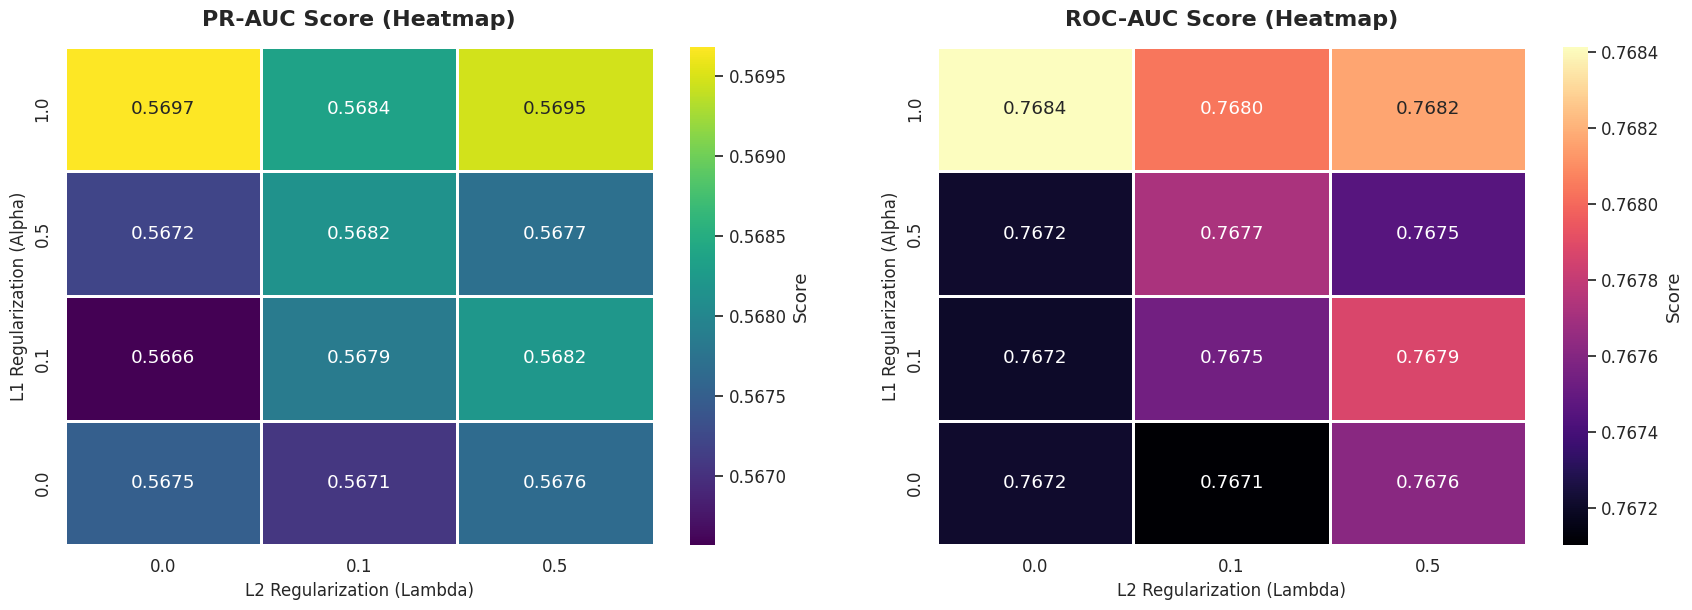


✅ Plot saved as 'regularization_heatmap.png'.
💡 COMMENT: As seen in the graph, performance increases as Alpha (L1) value increases (moving up the Y-axis).
The best result is achieved at Alpha=1.0 and Lambda=0.0.


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- VISUALIZING REGULARIZATION RESULTS ---")

# 1. Load Data
try:
    df = pd.read_csv('regularization_comparison_report.csv')
    print("✅ Data loaded successfully.")
except FileNotFoundError:
    # Manual data fallback if file is missing
    data = {
        'reg_alpha': [1.0, 1.0, 1.0, 0.1, 0.5, 0.1, 0.5, 0.0, 0.0, 0.5, 0.0, 0.1],
        'reg_lambda': [0.0, 0.5, 0.1, 0.5, 0.1, 0.1, 0.5, 0.5, 0.0, 0.0, 0.1, 0.0],
        'PR-AUC': [0.5697, 0.5695, 0.5684, 0.5682, 0.5682, 0.5679, 0.5677, 0.5676, 0.5675, 0.5672, 0.5671, 0.5666],
        'ROC-AUC': [0.7684, 0.7682, 0.7680, 0.7679, 0.7677, 0.7675, 0.7675, 0.7676, 0.7672, 0.7672, 0.7671, 0.7672]
    }
    df = pd.DataFrame(data)
    print("⚠️ File not found, using manual data for visualization.")

# Visual Settings
sns.set(style="white", font_scale=1.1)
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- CHART 1: PR-AUC (Primary Metric) ---
# Create Pivot Table
pivot_pr = df.pivot(index='reg_alpha', columns='reg_lambda', values='PR-AUC')
pivot_pr = pivot_pr.sort_index(ascending=False) # Sort Y-axis descending

# Draw Heatmap
sns.heatmap(pivot_pr, annot=True, fmt=".4f", cmap="viridis",
            linewidths=1, linecolor='white', ax=ax[0], cbar_kws={'label': 'Score'})
ax[0].set_title('PR-AUC Score (Heatmap)', fontsize=16, weight='bold', pad=15)
ax[0].set_ylabel('L1 Regularization (Alpha)', fontsize=12)
ax[0].set_xlabel('L2 Regularization (Lambda)', fontsize=12)

# Find Best Value for Highlights
best_row = df.loc[df['PR-AUC'].idxmax()]

# --- CHART 2: ROC-AUC (Secondary Metric) ---
pivot_roc = df.pivot(index='reg_alpha', columns='reg_lambda', values='ROC-AUC')
pivot_roc = pivot_roc.sort_index(ascending=False)

sns.heatmap(pivot_roc, annot=True, fmt=".4f", cmap="magma",
            linewidths=1, linecolor='white', ax=ax[1], cbar_kws={'label': 'Score'})
ax[1].set_title('ROC-AUC Score (Heatmap)', fontsize=16, weight='bold', pad=15)
ax[1].set_ylabel('L1 Regularization (Alpha)', fontsize=12)
ax[1].set_xlabel('L2 Regularization (Lambda)', fontsize=12)

plt.tight_layout(pad=3.0)
plt.savefig('regularization_heatmap.png', dpi=300)
plt.show()

print("\n✅ Plot saved as 'regularization_heatmap.png'.")
print(f"💡 COMMENT: As seen in the graph, performance increases as Alpha (L1) value increases (moving up the Y-axis).")
print(f"The best result is achieved at Alpha={best_row['reg_alpha']} and Lambda={best_row['reg_lambda']}.")

# Last training for gaining the learning curve (with best hyperparams)


--- FINAL MODEL ROBUSTNESS TEST (LEARNING CURVE) ---
Training with params:
{'n_estimators': 2000, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 30, 'reg_alpha': 1.0, 'reg_lambda': 0.5, 'class_weight': 'balanced', 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1}
Training started... Monitoring progress...
[LightGBM] [Info] Number of positive: 107230, number of negative: 300398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 5.890543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1261276
[LightGBM] [Info] Number of data points in the train set: 407628, number of used features: 5023
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[100]	Train's binary_logloss: 0.

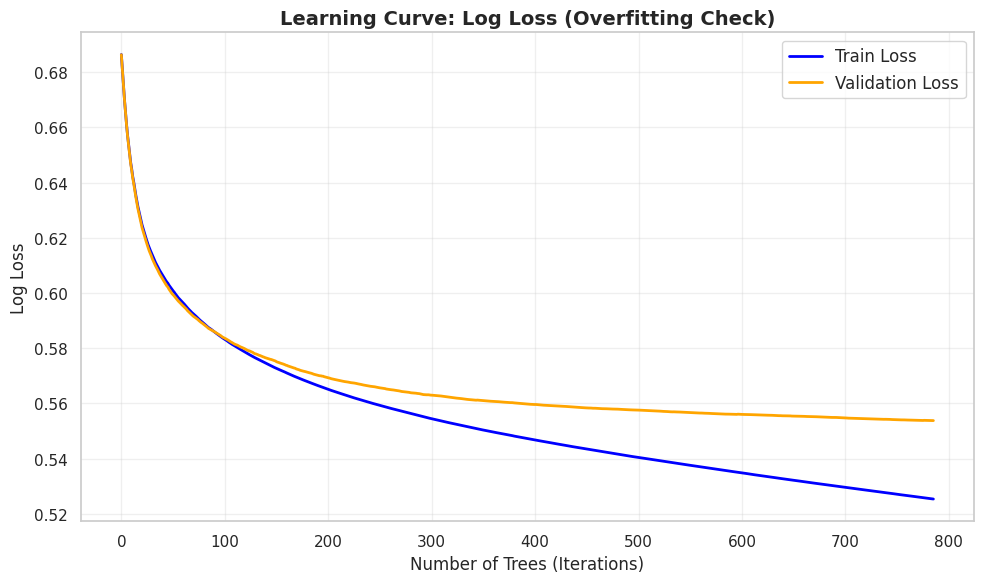

✅ Saved: learning_curve_logloss.png


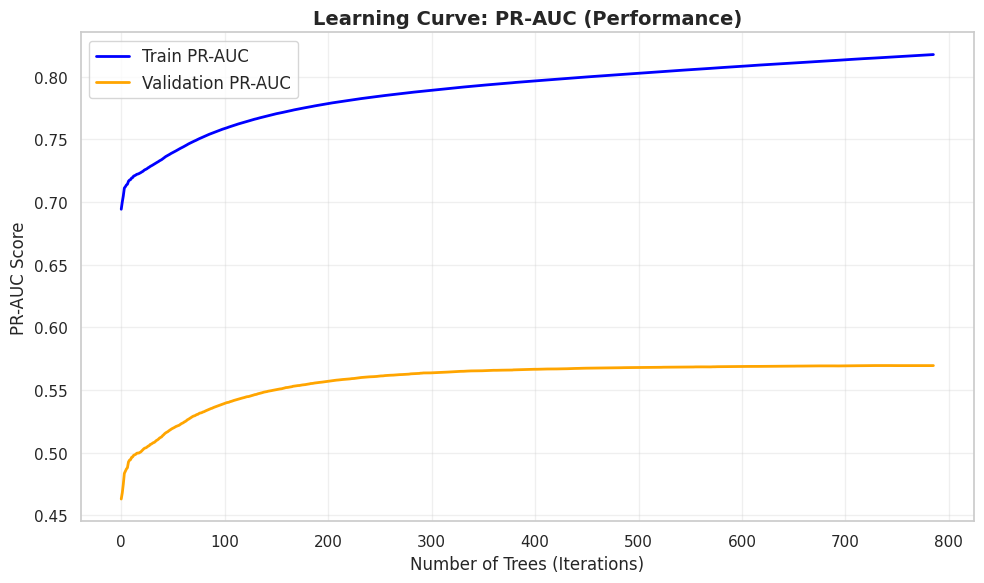

✅ Saved: learning_curve_prauc.png


In [32]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Görsel ayarları (İngilizce Rapor İçin)
sns.set(style="whitegrid")

print("--- FINAL MODEL ROBUSTNESS TEST (LEARNING CURVE) ---")

# 1. PARAMETERS ()
final_params = {
    'n_estimators': 2000,       # Yüksek veriyoruz ki nerede duracağını görelim
    'learning_rate': 0.05,      # İdeal hız
    'num_leaves': 31,           # İdeal karmaşıklık
    'max_depth': 30,            # İdeal derinlik
    'reg_alpha': 1.0,
    'reg_lambda': 0.5,
    'class_weight': 'balanced',
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
}

print(f"Training with params:\n{final_params}")

# 2. INITIALIZE MODEL
clf = lgb.LGBMClassifier(**final_params)

# 3. TRAINING (With History)
print("Training started... Monitoring progress...")

# eval_names kısmını İngilizce yaptık ki grafiklerde düzgün çıksın
clf.fit(
    X_train_final, y_train,
    eval_set=[(X_train_final, y_train), (X_val_final, y_val)],
    eval_names=['Train', 'Validation'],
    eval_metric=['binary_logloss', 'average_precision'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)

# 4. PLOTTING (SEPARATE FILES)
results = clf.evals_result_
epochs = len(results['Train']['binary_logloss'])
x_axis = range(0, epochs)

# --- GRAPH 1: LOG LOSS (Overfitting Check) ---
plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['Train']['binary_logloss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(x_axis, results['Validation']['binary_logloss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Learning Curve: Log Loss (Overfitting Check)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trees (Iterations)', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_logloss.png', dpi=300)
plt.show()
print("✅ Saved: learning_curve_logloss.png")

# --- GRAPH 2: PR-AUC (Performance) ---
plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['Train']['average_precision'], label='Train PR-AUC', color='blue', linewidth=2)
plt.plot(x_axis, results['Validation']['average_precision'], label='Validation PR-AUC', color='orange', linewidth=2)
plt.title('Learning Curve: PR-AUC (Performance)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trees (Iterations)', fontsize=12)
plt.ylabel('PR-AUC Score', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_prauc.png', dpi=300)
plt.show()
print("✅ Saved: learning_curve_prauc.png")